# Evolution Plots

In [2]:
import diffusers
from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor
import torch
import cv2
import numpy as np
import os
import random
from tqdm import tqdm
from PIL import Image 

/home/sonia/miniconda3/envs/svd/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# -------- helper to draw black outline & hide ticks --------
def outline_axes(ax, color='k', lw=1.0):
    # ensure frame visible
    ax.set_frame_on(True)
    # black spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(lw)
    # no ticks / labels
    ax.tick_params(
        axis='both',
        which='both',
        bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False
    )

/tmp/ipykernel_818876/1489381221.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap('viridis', len(levels) - 1)


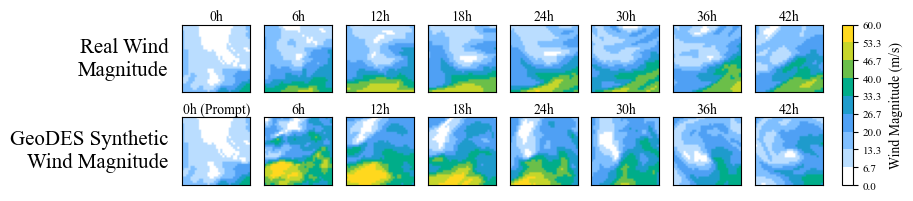

In [29]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ---------------- TMLR FONT CONFIGURATION ----------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 9,             
    'axes.titlesize': 10,
    'axes.labelsize': 10,       
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11
})
# ---------------------------------------------------------

expname = 'run3'
os.makedirs(expname, exist_ok=True)

sid = '20180215220325015300'
realsetpath = '/home/cyclone/train/multivar/0.25/date/natlantic/test/'
synthsetpath = '/mnt/data/sonia/geodes-samples/paper/main/main_3d_3_6365038_stochsample3'

realpath = os.path.join(realsetpath, sid)
synthpath = os.path.join(synthsetpath, sid)

# Load real storm data
real = []
for i in range(8):
    img = np.load(f'{realpath}/{i}.npy')  
    img = np.sqrt(img[:,:,1]**2 + img[:,:,2]**2)
    img = np.flip(img, axis=0)
    real.append(img)
    
# Load synth storm data
synth = []
for i in range(8):
    img = np.load(f'{synthpath}/{i}.npy').squeeze()
    img = np.sqrt(img[:,:,1]**2 + img[:,:,2]**2)
    img = np.flip(img, axis=0)
    synth.append(img)
    
maxp = 60
minp = 0
    
# Define discrete levels and colormap
levels = list(range(0, 100, 10))
base = plt.cm.get_cmap('viridis', len(levels) - 1)
colors = base(np.arange(base.N))

colors[0] = (1.0, 1.0, 1.0, 1.0)
colors[1] = (0.73, 0.87, 1.00, 1.0) 
colors[2] = (0.50, 0.75, 1.00, 1.0) 
colors[3] = (0.31, 0.63, 0.96, 1.0) 
colors[4] = (0.12, 0.61, 0.80, 1.0) 
colors[5] = (0.00, 0.68, 0.54, 1.0) 
colors[6] = (0.42, 0.75, 0.29, 1.0) 
colors[7] = (0.78, 0.84, 0.17, 1.0) 
colors[8] = (1.00, 0.85, 0.12, 1.0) 

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

def clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])

# ---------------- FIGURE SETUP ----------------
fig, axes = plt.subplots(2, 8, figsize=(9, 1.9), 
                         gridspec_kw={'wspace': 0.01, 'hspace': 0.1}, 
                         constrained_layout=True)

# ---------------- REAL SUBPLOT (TOP ROW) ----------------
for i in range(8):
    img = real[i]
    img = img - minp 
    img = img / (maxp - minp)  
    img = 100 * img
    img = img.astype(np.uint8)
    axes[0, i].imshow(img, cmap=cmap, norm=norm)
    axes[0, i].set_title(f'{i*6}h', pad=3)
    clean_axes(axes[0, i])
    
# Updated: Set rotation to 0 and align right
axes[0, 0].set_ylabel('Real Wind\nMagnitude', #fontweight='bold', 
                      rotation=0, ha='right', va='center', labelpad=10, fontsize=15)

# ---------------- SYNTH SUBPLOT (BOTTOM ROW) ----------------
for i in range(8):
    img = synth[i]
    img = img - minp 
    img = img / (maxp - minp)  
    img = 100 * img
    img = img.astype(np.uint8)
    axes[1, i].imshow(img, cmap=cmap, norm=norm)
    if i == 0:
        axes[1, i].set_title('0h (Prompt)', pad=3) 
    else:
        axes[1, i].set_title(f'{i*6}h', pad=3)
    clean_axes(axes[1, i])

# Updated: Set rotation to 0 and align right
axes[1, 0].set_ylabel('GeoDES Synthetic\nWind Magnitude', #fontweight='bold', 
                      rotation=0, ha='right', va='center', labelpad=10, fontsize=15)

# ---------------- COLORBAR (RIGHT SIDE) ----------------
real_levels = np.linspace(0, maxp, len(levels))
norm_unnormalized = mcolors.BoundaryNorm(boundaries=real_levels, ncolors=cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_unnormalized)
sm.set_array([]) 

cbar = fig.colorbar(sm, ax=axes, orientation='vertical', aspect=15, pad=0.03,)# shrink=0.95)
cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
cbar.set_label('Wind Magnitude (m/s)', labelpad=5, fontsize=10)

plt.savefig(f'demo.pdf', format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_818876/61202817.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap('viridis', len(levels) - 1)


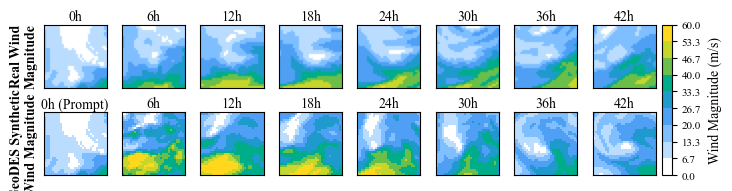

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ---------------- TMLR FONT CONFIGURATION ----------------
# TMLR uses a Times New Roman-based serif font. 
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'serif'],
    'mathtext.fontset': 'stix', # Matches Times New Roman for math symbols
    'font.size': 9,             # Base font size
    'axes.titlesize': 10,
    'axes.labelsize': 10,       # Bumped slightly to balance left-side labels
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11
})
# ---------------------------------------------------------

expname = 'run3'
os.makedirs(expname, exist_ok=True)

sid = '20180215220325015300'
realsetpath = '/home/cyclone/train/multivar/0.25/date/natlantic/test/'
synthsetpath = '/mnt/data/sonia/geodes-samples/paper/main/main_3d_3_6365038_stochsample3'
# sids = os.listdir(synthsetpath) # Commented out unless you need it later

realpath = os.path.join(realsetpath, sid)
synthpath = os.path.join(synthsetpath, sid)

# Load real storm data
real = []
for i in range(8):
    # Simulated load for example purposes; replace with your actual np.load
    img = np.load(f'{realpath}/{i}.npy')  
    img = np.sqrt(img[:,:,1]**2 + img[:,:,2]**2)
    img = np.flip(img, axis=0)
    real.append(img)
    
# Load synth storm data
synth = []
for i in range(8):
    img = np.load(f'{synthpath}/{i}.npy').squeeze()
    img = np.sqrt(img[:,:,1]**2 + img[:,:,2]**2)
    img = np.flip(img, axis=0)
    synth.append(img)
    
maxp = 60
minp = 0
    
# Define discrete levels and colormap
levels = list(range(0, 100, 10))
base = plt.cm.get_cmap('viridis', len(levels) - 1)
colors = base(np.arange(base.N))

colors[0] = (1.0, 1.0, 1.0, 1.0)
colors[1] = (0.73, 0.87, 1.00, 1.0) 
colors[2] = (0.50, 0.75, 1.00, 1.0) 
colors[3] = (0.31, 0.63, 0.96, 1.0) 
colors[4] = (0.12, 0.61, 0.80, 1.0) 
colors[5] = (0.00, 0.68, 0.54, 1.0) 
colors[6] = (0.42, 0.75, 0.29, 1.0) 
colors[7] = (0.78, 0.84, 0.17, 1.0) 
colors[8] = (1.00, 0.85, 0.12, 1.0) 

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

# Helper to clear ticks
def clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])

# ---------------- FIGURE SETUP ----------------
# Use a unified grid rather than subfigures to squash vertical empty space
# Height is squeezed to 1.8 to force the rows together.
fig, axes = plt.subplots(2, 8, figsize=(7.2, 1.8), 
                         gridspec_kw={'wspace': 0.02, 'hspace': 0.1}, 
                         constrained_layout=True)

# ---------------- REAL SUBPLOT (TOP ROW) ----------------
for i in range(8):
    img = real[i]
    img = img - minp 
    img = img / (maxp - minp)  
    img = 100 * img
    img = img.astype(np.uint8)
    axes[0, i].imshow(img, cmap=cmap, norm=norm)
    axes[0, i].set_title(f'{i*6}h', pad=3)
    clean_axes(axes[0, i])
    
# Apply the label to the very first image on the left
axes[0, 0].set_ylabel('Real Wind\nMagnitude', fontweight='bold')

# ---------------- SYNTH SUBPLOT (BOTTOM ROW) ----------------
for i in range(8):
    img = synth[i]
    img = img - minp 
    img = img / (maxp - minp)  
    img = 100 * img
    img = img.astype(np.uint8)
    axes[1, i].imshow(img, cmap=cmap, norm=norm)
    if i == 0:
        axes[1, i].set_title('0h (Prompt)', pad=3) 
    else:
        axes[1, i].set_title(f'{i*6}h', pad=3)
    clean_axes(axes[1, i])

# Apply the label to the very first image on the left
axes[1, 0].set_ylabel('GeoDES Synthetic\nWind Magnitude', fontweight='bold')

# ---------------- COLORBAR (RIGHT SIDE) ----------------
real_levels = np.linspace(0, maxp, len(levels))
norm_unnormalized = mcolors.BoundaryNorm(boundaries=real_levels, ncolors=cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_unnormalized)
sm.set_array([]) 

# Passing ax=axes tells constrained_layout to span the colorbar next to the entire grid
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', aspect=15, pad=0.01)
cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
cbar.set_label('Wind Magnitude (m/s)', labelpad=5, fontsize=10)

plt.savefig(f'demo.pdf', format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_818876/1329748229.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap('viridis', len(levels) - 1)


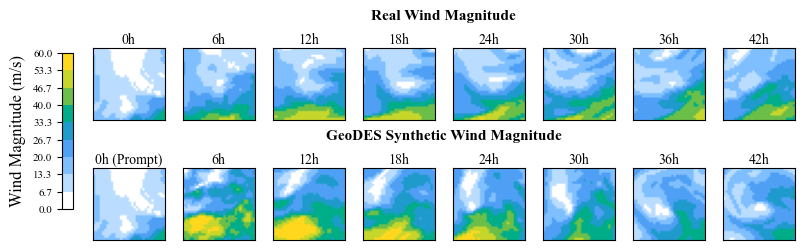

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ---------------- TMLR FONT CONFIGURATION ----------------
# TMLR uses a Times New Roman-based serif font. 
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'serif'],
    'mathtext.fontset': 'stix', # Matches Times New Roman for math symbols
    'font.size': 9,             # Base font size
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11
})
# ---------------------------------------------------------

expname = 'run3'
os.makedirs(expname, exist_ok=True)

sid = '20180215220325015300'
realsetpath = '/home/cyclone/train/multivar/0.25/date/natlantic/test/'
synthsetpath = '/mnt/data/sonia/geodes-samples/paper/main/main_3d_3_6365038_stochsample3'
sids = os.listdir(synthsetpath)

# Optimized figsize for text-width portrait page (Width: ~7.2in, Height: ~3.2in)
fig = plt.figure(figsize=(7.2, 2.4), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.05, hspace=0, wspace=0.02)

# top and bottom subfigures
subfigs = fig.subfigures(2,1)#, wspace=0.03)

realpath = os.path.join(realsetpath, sid)
synthpath = os.path.join(synthsetpath, sid)

# Load real storm data
real = []
for i in range(8):
    # Simulated load for example purposes; replace with your actual np.load
    img = np.load(f'{realpath}/{i}.npy')  
    img = np.sqrt(img[:,:,1]**2 + img[:,:,2]**2)
    img = np.flip(img, axis=0)
    real.append(img)
    
# Load synth storm data
synth = []
for i in range(8):
    img = np.load(f'{synthpath}/{i}.npy').squeeze()
    img = np.sqrt(img[:,:,1]**2 + img[:,:,2]**2)
    img = np.flip(img, axis=0)
    synth.append(img)
    
maxp = 60#max([np.max(p) for p in synth])
minp = 0#min([np.min(p) for p in synth])
    
# Define discrete levels and colormap
levels = list(range(0, 100, 10))
base = plt.cm.get_cmap('viridis', len(levels) - 1)
colors = base(np.arange(base.N))

colors[0] = (1.0, 1.0, 1.0, 1.0)
colors[1] = (0.73, 0.87, 1.00, 1.0) 
colors[2] = (0.50, 0.75, 1.00, 1.0) 
colors[3] = (0.31, 0.63, 0.96, 1.0) 
colors[4] = (0.12, 0.61, 0.80, 1.0) 
colors[5] = (0.00, 0.68, 0.54, 1.0) 
colors[6] = (0.42, 0.75, 0.29, 1.0) 
colors[7] = (0.78, 0.84, 0.17, 1.0) 
colors[8] = (1.00, 0.85, 0.12, 1.0) 

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

# Helper to clear ticks
def clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])

# ---------------- REAL SUBPLOT (LEFT) ----------------
subfigs[0].suptitle('Real Wind Magnitude', fontweight='bold')
axes_real = subfigs[0].subplots(1, 8, sharex=True, sharey=True, 
                                gridspec_kw={'wspace': 0, 'hspace': -5})
axes_real = axes_real.flatten() 

for i in range(8):
    img = real[i]
    img = img - minp 
    img = img / (maxp - minp)  
    img = 100 * img
    img = img.astype(np.uint8)
    axes_real[i].imshow(img, cmap=cmap, norm=norm)
    axes_real[i].set_title(f'{i*6}h', pad=3)
    clean_axes(axes_real[i])
    # outline_axes(axes_real[i])
    
# ---------------- SYNTH SUBPLOT (RIGHT) ----------------
subfigs[1].suptitle('GeoDES Synthetic Wind Magnitude', fontweight='bold')
axes_synth = subfigs[1].subplots(1, 8, sharex=True, sharey=True, 
                                 gridspec_kw={'wspace': 0, 'hspace': -5})
axes_synth = axes_synth.flatten() 

for i in range(8):
    img = synth[i]
    img = img - minp 
    img = img / (maxp - minp)  
    img = 100 * img
    img = img.astype(np.uint8)
    axes_synth[i].imshow(img, cmap=cmap, norm=norm)
    if i == 0:
        axes_synth[i].set_title('0h (Prompt)', pad=3) # P for Prompt
    else:
        axes_synth[i].set_title(f'{i*6}h', pad=3)
    clean_axes(axes_synth[i])
    # outline_axes(axes_synth[i])

# ---------------- COLORBAR (RIGHT SIDE) ----------------
real_levels = np.linspace(0, maxp, len(levels))
norm_unnormalized = mcolors.BoundaryNorm(boundaries=real_levels, ncolors=cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_unnormalized)
sm.set_array([]) 

# CHANGED: 'left' coordinate is now -0.06 to place it on the far left
cbar_ax = fig.add_axes([-0.03, 0.15, 0.015, 0.65]) 
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')

# CHANGED: Move the ticks and label to the left side of the colorbar
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
cbar.set_label('Wind Magnitude (m/s)', labelpad=5, fontsize=12)

plt.savefig(f'demo.pdf', format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_302760/2897310679.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap('viridis', len(levels) - 1)


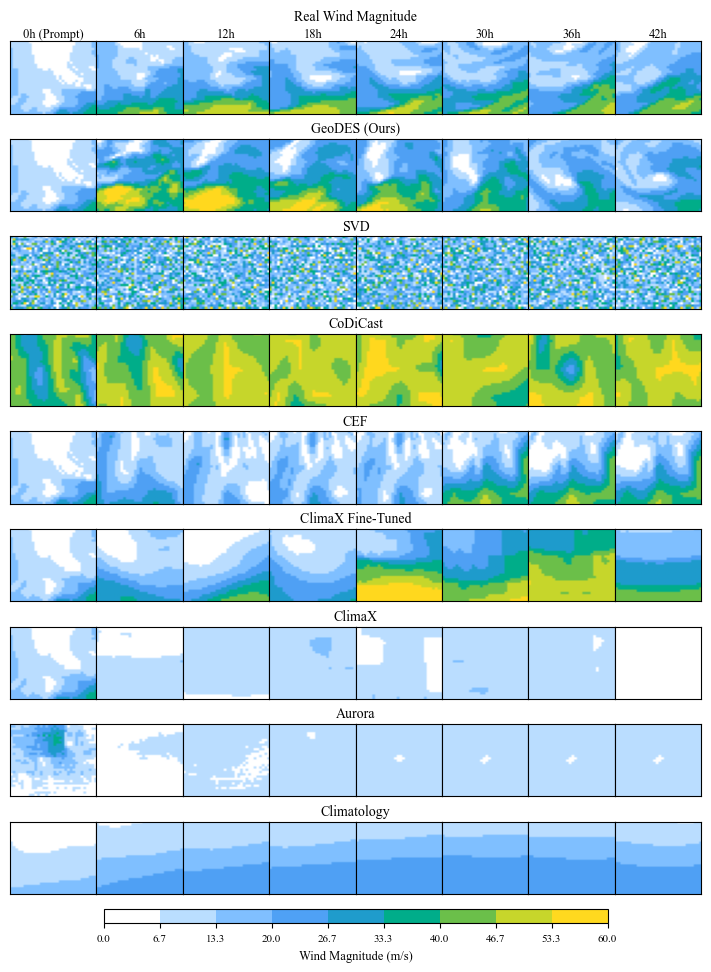

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ---------------- TMLR FONT CONFIGURATION ----------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,             
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 11
})
# ---------------------------------------------------------

# --- LOAD DATA ---
sid = '20180215220325015300'
paths = [
    '/home/cyclone/train/multivar/0.25/date/natlantic/test/',
    '/mnt/data/sonia/geodes-samples/paper/main/main_3d_3_6365038_stochsample3',
    '/mnt/data/sonia/svd/multivar/samples',
    '/mnt/data/sonia/codicast-out/date/multivar/patches/onepast1',
    '/mnt/data/sonia/cef/patches/multivar/1',
    '/mnt/data/sonia/climax-data/date/extracted-ft-natlantic-multivar-fullcontext1',
    '/mnt/data/sonia/climax-data/date/extracted-natlantic-multivar-fullcontext/test',
    '/mnt/data/sonia/aurora-out/date/patches-natlantic-multivar-fullcontext/test',
    '/mnt/data/sonia/clima_patches/date/natlantic-multivar-0.25/test',
]

all_data = []
for path in paths:
    data = []
    for i in range(8):
        img = np.load(os.path.join(path, sid, f'{i}.npy')).squeeze()
        if 'svd' in path:
            img = np.sqrt(img[1]**2 + img[2]**2)
        else:
            img = np.sqrt(img[:,:,1]**2 + img[:,:,2]**2)
        if 'codicast' in path:
            img = img/1.8
        elif 'aurora' in path:
            img=img*1.4
        img = np.flip(img, axis=0)
        data.append(img)
    all_data.append(data)

titles = [
    'Real Wind Magnitude', 'GeoDES (Ours)', 'SVD', 
    'CoDiCast', 'CEF', 'ClimaX Fine-Tuned', 
    'ClimaX', 'Aurora', 'Climatology'
]

maxp = 60
minp = 0
    
# --- COLORMAP ---
levels = list(range(0, 100, 10))
base = plt.cm.get_cmap('viridis', len(levels) - 1)
colors = base(np.arange(base.N))

colors[0] = (1.0, 1.0, 1.0, 1.0)
colors[1] = (0.73, 0.87, 1.00, 1.0) 
colors[2] = (0.50, 0.75, 1.00, 1.0) 
colors[3] = (0.31, 0.63, 0.96, 1.0) 
colors[4] = (0.12, 0.61, 0.80, 1.0) 
colors[5] = (0.00, 0.68, 0.54, 1.0) 
colors[6] = (0.42, 0.75, 0.29, 1.0) 
colors[7] = (0.78, 0.84, 0.17, 1.0) 
colors[8] = (1.00, 0.85, 0.12, 1.0) 

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

def clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])

# --- FIGURE & RIGID MATRIX ---
# CHANGED: We are NOT using constrained_layout=True anymore.
fig, axes = plt.subplots(nrows=9, ncols=8, figsize=(7.2, 9.8))

# CHANGED: Manually enforce zero horizontal space (wspace=0.0). 
# hspace=0.35 gives just enough vertical room for the row titles.
fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.08, wspace=0.0, hspace=0.35)

# --- PLOTTING LOOP ---
for row in range(9):
    data = all_data[row]
    
    # CHANGED: Center the model title perfectly above this row.
    # By placing text at x=1.0 on column 3, it hangs exactly in the middle of the 8 columns.
    if row==0:
        height=1.25
    else:
        height=1.05 
    axes[row, 3].text(1.0, height, titles[row], ha='center', va='bottom', 
                      transform=axes[row, 3].transAxes, fontsize=10)
    
    for col in range(8):
        img = data[col]
        img = img - minp 
        img = img / (maxp - minp)  
        img = 100 * img
        img = img.astype(np.uint8)
        
        # CHANGED: aspect='auto' forces it into the zero-gap grid cell. 
        # Because we optimized the figsize, they will appear perfectly square visually.
        axes[row, col].imshow(img, cmap=cmap, norm=norm, aspect='auto')
        
        # Only put the '0h', '6h' labels on the very top row
        if row == 0:
            if col == 0: 
                axes[row, col].set_title('0h (Prompt)', pad=3, fontsize=9)
            else:
                axes[row, col].set_title(f'{col*6}h', pad=3, fontsize=9)
            
        clean_axes(axes[row, col])

# --- COLORBAR (BOTTOM HORIZONTAL) ---
real_levels = np.linspace(0, maxp, len(levels))
norm_unnormalized = mcolors.BoundaryNorm(boundaries=real_levels, ncolors=cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_unnormalized)
sm.set_array([]) 

# Tucked at the bottom of the page in the empty margin space
# [left, bottom, width, height]
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.015])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')

cbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
cbar.set_label('Wind Magnitude (m/s)', labelpad=5)

plt.savefig('compare_windmag.pdf', format='pdf')
plt.show()